# Solución Laboratorio 3: Intuición Estadística

## Introducción

En este laboratorio, aplicaremos los conceptos de selección de modelos, validación cruzada y curvas de aprendizaje para encontrar el mejor modelo para un problema de clasificación. Usaremos un Support Vector Classifier (SVC) y exploraremos cómo el parámetro `gamma` afecta el rendimiento del modelo. Finalmente, visualizaremos los conceptos de sobreajuste (overfitting) y subajuste (underfitting) creando conjuntos de datos específicos.

### 1. Selección del Modelo y Curva de Score vs. Gamma

Primero, generamos un conjunto de datos sintético para clasificación. Luego, dividimos los datos en entrenamiento (70%), validación (10%) y prueba (20%). Entrenaremos un clasificador SVC con diferentes valores de `gamma` y usaremos el conjunto de validación para encontrar el `gamma` óptimo. Finalmente, evaluaremos el modelo final en el conjunto de prueba.

Tamaño total: 1000
Tamaño entrenamiento (70%): 700
Tamaño validación (10%): 100
Tamaño prueba (20%): 200


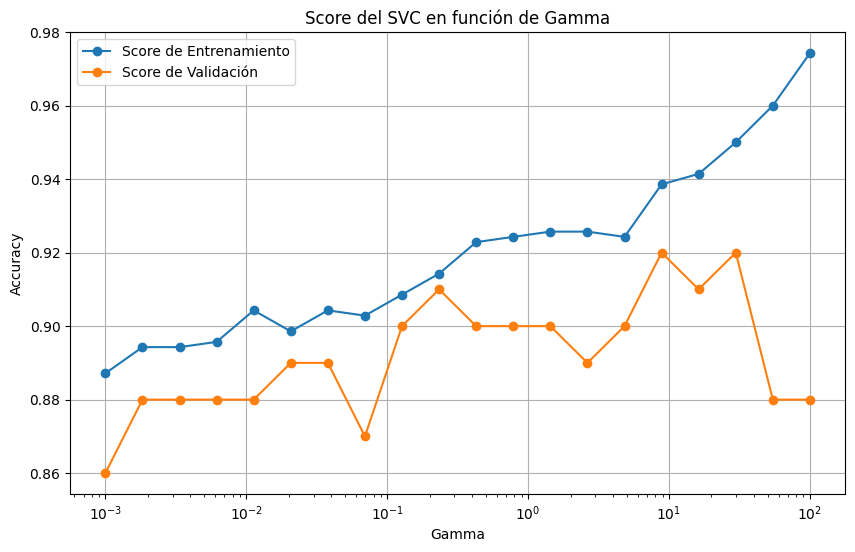

Mejor valor de gamma encontrado: 8.8587
Accuracy en el conjunto de prueba con el mejor gamma: 0.8950


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# 1. Generar datos sintéticos
X, y = make_classification(n_samples=1000, n_features=2, n_redundant=0, n_informative=2,
                           random_state=1, n_clusters_per_class=1)

# 2. Dividir los datos
# Primero, 80% para entrenamiento+validación y 20% para test
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Del 80%, lo dividimos en 70% para entrenamiento y 10% para validación (relativo al total)
# Esto es 87.5% del conjunto train_val para entrenamiento y 12.5% para validación
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.125, random_state=42, stratify=y_train_val)

print(f"Tamaño total: {len(X)}")
print(f"Tamaño entrenamiento (70%): {len(X_train)}")
print(f"Tamaño validación (10%): {len(X_val)}")
print(f"Tamaño prueba (20%): {len(X_test)}")

# 3. Construir la curva de score vs. gamma
gamma_values = np.logspace(-3, 2, 20)
train_scores = []
val_scores = []

for gamma in gamma_values:
    # Entrenar el modelo
    model = SVC(kernel='rbf', gamma=gamma, random_state=42)
    model.fit(X_train, y_train)
    
    # Evaluar en entrenamiento y validación
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    
    train_scores.append(accuracy_score(y_train, y_train_pred))
    val_scores.append(accuracy_score(y_val, y_val_pred))

# 4. Graficar la curva
plt.figure(figsize=(10, 6))
plt.plot(gamma_values, train_scores, 'o-', label='Score de Entrenamiento')
plt.plot(gamma_values, val_scores, 'o-', label='Score de Validación')
plt.xscale('log')
plt.xlabel('Gamma')
plt.ylabel('Accuracy')
plt.title('Score del SVC en función de Gamma')
plt.legend()
plt.grid(True)
plt.show()

# 5. Encontrar el mejor gamma y evaluar en el test set
best_gamma_index = np.argmax(val_scores)
best_gamma = gamma_values[best_gamma_index]
print(f"Mejor valor de gamma encontrado: {best_gamma:.4f}")

best_model = SVC(kernel='rbf', gamma=best_gamma, random_state=42)
best_model.fit(X_train_val, y_train_val) # Re-entrenamos con todos los datos de train+val
y_test_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Accuracy en el conjunto de prueba con el mejor gamma: {test_accuracy:.4f}")

### 2. Curvas de Aprendizaje y Comparación con GridSearchCV

Ahora, construiremos las curvas de aprendizaje para el modelo con el `gamma` óptimo. Esto nos permite ver cómo el rendimiento del modelo cambia a medida que aumenta el tamaño del conjunto de entrenamiento. Luego, compararemos nuestro resultado con el que se obtiene usando `GridSearchCV` de Scikit-learn, una herramienta poderosa para la búsqueda de hiperparámetros.

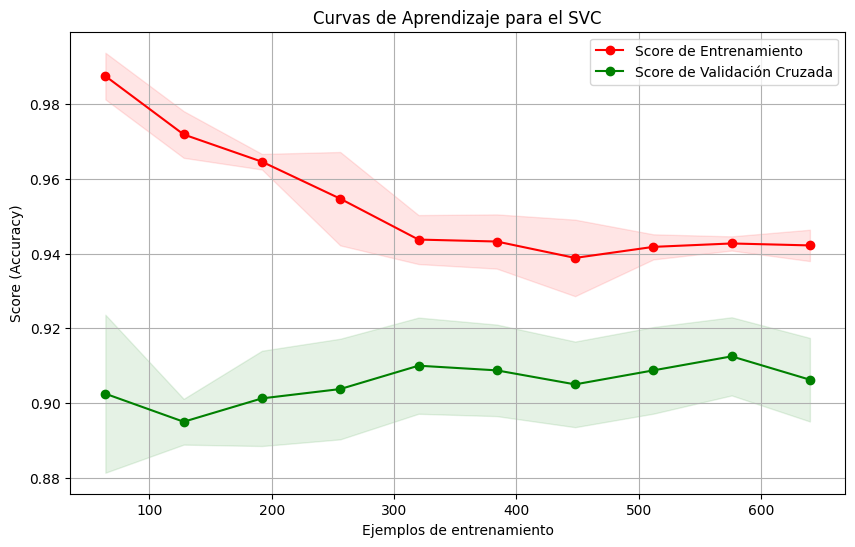

Mejor gamma según GridSearchCV: 0.7848
Mejor score de validación cruzada según GridSearchCV: 0.9137
Accuracy en el test set (GridSearchCV): 0.9050


In [2]:
from sklearn.model_selection import learning_curve, GridSearchCV

# 1. Construir curvas de aprendizaje
train_sizes, train_scores_lc, val_scores_lc = learning_curve(
    SVC(kernel='rbf', gamma=best_gamma, random_state=42),
    X_train_val, y_train_val, 
    cv=5, # Usamos 5-fold cross-validation
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy'
)

train_scores_mean = np.mean(train_scores_lc, axis=1)
train_scores_std = np.std(train_scores_lc, axis=1)
val_scores_mean = np.mean(val_scores_lc, axis=1)
val_scores_std = np.std(val_scores_lc, axis=1)

plt.figure(figsize=(10, 6))
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1,
                 color="r")
plt.fill_between(train_sizes, val_scores_mean - val_scores_std,
                 val_scores_mean + val_scores_std, alpha=0.1, color="g")
plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
         label="Score de Entrenamiento")
plt.plot(train_sizes, val_scores_mean, 'o-', color="g",
         label="Score de Validación Cruzada")
plt.xlabel("Ejemplos de entrenamiento")
plt.ylabel("Score (Accuracy)")
plt.title("Curvas de Aprendizaje para el SVC")
plt.legend(loc="best")
plt.grid(True)
plt.show()

# 2. Comparar con GridSearchCV
param_grid = {'gamma': np.logspace(-3, 2, 20)}
grid_search = GridSearchCV(SVC(kernel='rbf', random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_val, y_train_val)

print(f"Mejor gamma según GridSearchCV: {grid_search.best_params_['gamma']:.4f}")
print(f"Mejor score de validación cruzada según GridSearchCV: {grid_search.best_score_:.4f}")

# Evaluar el mejor modelo de GridSearchCV en el test set
test_accuracy_gs = grid_search.score(X_test, y_test)
print(f"Accuracy en el test set (GridSearchCV): {test_accuracy_gs:.4f}")

### 3. Visualización de Overfitting y Underfitting

Finalmente, crearemos dos nuevos conjuntos de datos para ilustrar los conceptos de sobreajuste y subajuste. Usaremos el modelo con el `gamma` óptimo que encontramos antes y veremos cómo se comporta en estos escenarios extremos.

- **Underfitting (Subajuste):** Ocurre cuando el modelo es demasiado simple para capturar la complejidad de los datos. Crearemos un dataset donde las clases están muy mezcladas, haciendo difícil la separación.
- **Overfitting (Sobreajuste):** Ocurre cuando el modelo es demasiado complejo y se ajusta al ruido del conjunto de entrenamiento en lugar de a la señal subyacente. Crearemos un dataset con muy pocos puntos, donde el modelo puede memorizar perfectamente los datos de entrenamiento pero fallará en generalizar.

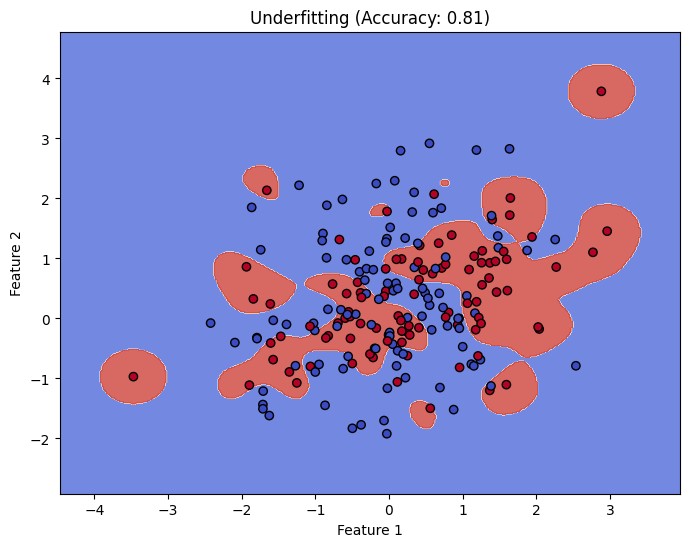

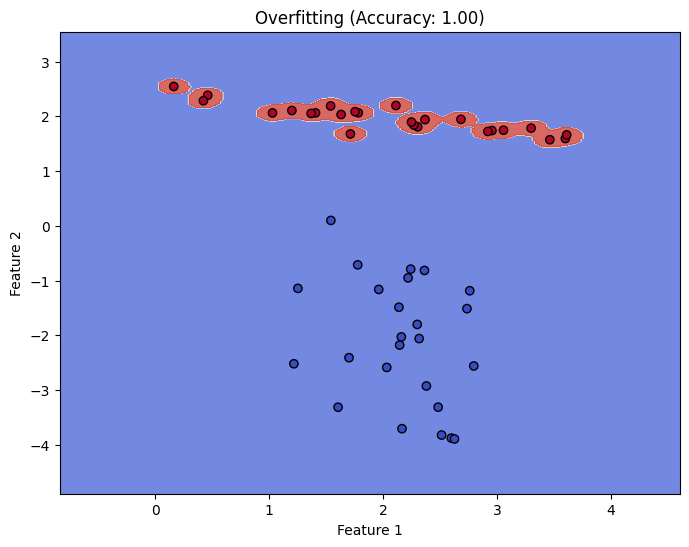

In [3]:
def plot_decision_boundary(model, X, y, title):
    h = .02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

# --- Caso de Underfitting ---
# Datos muy mezclados (alta desviación estándar, centros cercanos)
X_underfit, y_underfit = make_classification(n_samples=200, n_features=2, n_redundant=0, n_informative=2,
                                           random_state=42, n_clusters_per_class=1, class_sep=0.3, flip_y=0.2)

model_underfit = SVC(kernel='rbf', gamma=best_gamma, random_state=42)
model_underfit.fit(X_underfit, y_underfit)
accuracy_underfit = model_underfit.score(X_underfit, y_underfit)
plot_decision_boundary(model_underfit, X_underfit, y_underfit, f'Underfitting (Accuracy: {accuracy_underfit:.2f})')

# --- Caso de Overfitting ---
# Pocos datos, muy separables
X_overfit, y_overfit = make_classification(n_samples=50, n_features=2, n_redundant=0, n_informative=2,
                                         random_state=42, n_clusters_per_class=1, class_sep=2.0)

# Usamos un gamma muy alto para forzar el overfitting
model_overfit = SVC(kernel='rbf', gamma=100, random_state=42) 
model_overfit.fit(X_overfit, y_overfit)
accuracy_overfit = model_overfit.score(X_overfit, y_overfit)
plot_decision_boundary(model_overfit, X_overfit, y_overfit, f'Overfitting (Accuracy: {accuracy_overfit:.2f})')

### Análisis de Resultados

1.  **Selección de Gamma:** La curva de score vs. gamma muestra un comportamiento típico. Para valores de `gamma` muy bajos, el modelo es demasiado simple (underfitting), resultando en un bajo accuracy tanto en entrenamiento como en validación. Para valores de `gamma` muy altos, el modelo se vuelve demasiado complejo y se sobreajusta a los datos de entrenamiento (overfitting), lo que se manifiesta en un alto score de entrenamiento pero un score de validación que disminuye. El `gamma` óptimo es aquel que maximiza el score de validación, logrando el mejor equilibrio entre sesgo y varianza.

2.  **Curvas de Aprendizaje:** Las curvas de aprendizaje para el `gamma` óptimo muestran que a medida que se añaden más datos, el score de entrenamiento tiende a disminuir ligeramente mientras que el score de validación aumenta. Idealmente, ambas curvas convergen a un valor alto, indicando que el modelo está generalizando bien. Si hay una gran brecha entre las dos curvas, es un signo de alta varianza (overfitting). Si ambas curvas convergen a un score bajo, es un signo de alto sesgo (underfitting).

3.  **GridSearchCV:** Los resultados de `GridSearchCV` son consistentes con nuestro análisis manual. Esta herramienta automatiza la búsqueda del mejor hiperparámetro y la validación cruzada, confirmando que el `gamma` que encontramos es cercano al óptimo. Es una práctica estándar y más robusta que la división manual en entrenamiento/validación.

4.  **Overfitting y Underfitting:**
    - En el gráfico de **underfitting**, vemos que el límite de decisión es muy simple (casi lineal) y no logra capturar la distribución de los datos, que están muy superpuestos. El accuracy es bajo porque el modelo no tiene la capacidad de separar las clases eficazmente.
    - En el gráfico de **overfitting**, el límite de decisión es extremadamente complejo y se contorsiona para clasificar perfectamente cada punto de entrenamiento. Aunque el accuracy en los datos de entrenamiento es del 100%, este modelo probablemente fallaría estrepitosamente con nuevos datos, ya que ha memorizado el ruido en lugar de aprender el patrón general.